In [1]:
import numpy as np
import pandas as pd
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from ta import add_all_ta_features
import ta
from advanced_ta import LorentzianClassification
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:

prediction = {
    'NEUTRAL': 0,
    'BUY': 1,
    'SELL': 2
}

In [3]:
# from ta.trend import macd,cci,adx,macd_signal,adx_pos,adx_neg
# from ta.momentum import rsi,stochrsi_d,stochrsi_k,stochrsi
# def calculate(pd: pd.DataFrame,predict=True):
#     pdrsi = rsi(pd['close'],14)
#     # rsi.dropna(axis=0,inplace=True)
#     pdcci = cci(pd['high'],pd['low'],pd['close'],14)
#     # cci.dropna(axis=0,inplace=True)
#     pdadx = adx(pd['high'],pd['low'],pd['close'])
#     pdadx_pos = adx_pos(pd['high'],pd['low'],pd['low']) 
#     pdadx_neg = adx_neg(pd['high'],pd['low'],pd['low'])
#     # adx.dropna(axis=0,inplace=True)
#     pdmacd = macd(pd['close'])
#     # macd.dropna(axis=0,inplace=True)
#     pdmacd_signal = macd_signal(pd['close'])
#     # macd_signal.dropna(axis=0,inplace=True)
#     pdstochrsi_d = stochrsi_d(pd['close'])
#     pdstochrsi_k = stochrsi_k(pd['close'])
#     pdstochrsi = stochrsi(pd['close'])
#     # stochrsi.dropna(axis=0,inplace=True)
#     pd2 = pd.iloc[:,1:7].copy(deep=True) # iloc[row,column]
#     pd2['adx'] = pdadx
#     pd2['adx_pos'] = pdadx_pos
#     pd2['adx_neg'] = pdadx_neg
#     pd2['macd'] = pdmacd
#     pd2['macd_signal'] = pdmacd_signal
#     pd2['stochrsi_d'] = pdstochrsi_d
#     pd2['stochrsi_k'] = pdstochrsi_k
#     pd2['stochrsi'] = pdstochrsi
#     pd2['RSI'] = pdrsi.apply(lambda x: 1 if x < 30 else 2 if x > 70 else 0).astype(int)
#     pd2['CCI'] = pdcci.apply(lambda x: 1 if x < -100 else 2 if x > 100 else 0).astype(int)
#     conditions_3 = (pd2['stochrsi'] > 0.80) & (pd2['stochrsi_k'] < pd2['stochrsi_d'])
#     conditions_4 = (pd2['stochrsi'] < 0.20) & (pd2['stochrsi_k'] > pd2['stochrsi_d'])
#     pd2['STOCH.RSI'] = np.where(conditions_3, 2, np.where(conditions_4, 1, 0)).astype(int)
#     pd2['ADX'] = np.where((pd2['adx'] > 25.00) & (pd2['adx_pos'] > pd2['adx_neg']), 1, np.where((pd2['adx'] > 25.00) & (pd2['adx_pos'] < pd2['adx_neg']), 2, 0)).astype(int)
#     pd2['MCAD'] = np.where((pd2['macd'] > pd2['macd_signal']), 1, np.where(pd2['macd'] < pd2['macd_signal'], 2, 0)).astype(int)
#     if predict:
#         pd2['next_close'] = pd2['close'].shift(-1)
#     pd2.dropna(axis=0,inplace=True)
#     pd2.drop(columns=['adx','adx_pos','adx_neg','macd','macd_signal','stochrsi','stochrsi_d','stochrsi_k'],axis=1,inplace=True)
#     if predict:
#         counts_1 = pd2[['RSI', 'CCI', 'STOCH.RSI', 'ADX', 'MCAD']].eq(1).sum(axis=1)
#         counts_2 = pd2[['RSI', 'CCI', 'STOCH.RSI', 'ADX', 'MCAD']].eq(2).sum(axis=1)
#         pd2['Prediction'] = np.where((counts_1 > 2) & (pd2['open'] < pd2['next_close']), 1,
#                               np.where((counts_2 > 2) & (pd2['open'] > pd2['next_close']), 2, 0))
#         # condition = [pd2['RSI'],pd2['CCI'],pd2['STOCH.RSI'],pd2['ADX'],pd2['MCAD']]
#         # pd2['Prediction'] = np.where((condition.count(1) > 2) & (pd2['open'] < pd2['next_close']), 1,
#         #                         np.where((condition.count(2) > 2) & (pd2['open'] > pd2['next_close']), 2, 0)).astype(int)
#         pd2.drop(columns=['next_close'], inplace=True)
#     return pd2


In [20]:
from ta.trend import macd,cci,adx,macd_signal,adx_pos,adx_neg,sma_indicator,ema_indicator
from ta.momentum import rsi,stochrsi_d,stochrsi_k,stochrsi
def calculate_1(pd: pd.DataFrame,predict=True):
    pdrsi = rsi(pd['close'],14)
    # rsi.dropna(axis=0,inplace=True)
    pdcci = cci(pd['high'],pd['low'],pd['close'],14)
    # cci.dropna(axis=0,inplace=True)
    pdadx = adx(pd['high'],pd['low'],pd['close'])
    pdadx_pos = adx_pos(pd['high'],pd['low'],pd['low']) 
    pdadx_neg = adx_neg(pd['high'],pd['low'],pd['low'])
    # adx.dropna(axis=0,inplace=True)
    pdmacd = macd(pd['close'])
    # macd.dropna(axis=0,inplace=True)
    pdmacd_signal = macd_signal(pd['close'])
    # macd_signal.dropna(axis=0,inplace=True)
    pdstochrsi_d = stochrsi_d(pd['close'])
    pdstochrsi_k = stochrsi_k(pd['close'])
    pdstochrsi = stochrsi(pd['close'])
    # stochrsi.dropna(axis=0,inplace=True)
    pd2 = pd.iloc[:,0:7].copy(deep=True) # iloc[row,column]
    pd2['rsi'] = pdrsi
    pd2['cci'] = pdcci
    pd2['adx'] = pdadx
    pd2['adx_pos'] = pdadx_pos
    pd2['adx_neg'] = pdadx_neg
    pd2['macd'] = pdmacd
    pd2['macd_signal'] = pdmacd_signal
    pd2['stochrsi_d'] = pdstochrsi_d
    pd2['stochrsi_k'] = pdstochrsi_k
    pd2['stochrsi'] = pdstochrsi
    pd2['sma_av3'] = sma_indicator(pd['close'],3)
    pd2['sma_av6'] = sma_indicator(pd['close'],6)
    pd2['RSI'] = pdrsi.apply(lambda x: 1 if x < 30 else 2 if x > 70 else 0).astype('int32')
    # pd2['CCI'] = pdrsi.apply(lambda x: 1 if x < -150 else 2 if x > 150 else 0).astype('int32')
    # pd2['CCI'] = pdcci.apply(lambda x: 1 if x < -100 else 2 if x > 100 else 0).astype(int)
    # conditions_3 = (pd2['stochrsi'] > 80) & (pd2['stochrsi_k'] < pd2['stochrsi_d'])
    # conditions_4 = (pd2['stochrsi'] < 20) & (pd2['stochrsi_k'] > pd2['stochrsi_d'])
    # pd2['STOCH.RSI'] = np.where(conditions_3, 2, np.where(conditions_4, 1, 0)).astype(int)
    pd2['ADX'] = np.where((pd2['adx'] > 25.00) & (pd2['adx_pos'] > pd2['adx_neg']), 1, np.where((pd2['adx'] > 25.00) & (pd2['adx_pos'] < pd2['adx_neg']), 2, 0)).astype('int32')
    pd2['MCAD'] = np.where((pd2['macd'] > pd2['macd_signal']), 1, np.where(pd2['macd'] < pd2['macd_signal'], 2, 0)).astype('int32')
    pd2['next_close'] = pd2['close'].shift(-1)
    pd2.dropna(axis=0,inplace=True)
    pd2['SMA3'] = np.where((pd2['sma_av3'] > pd2['close']), 1,
                            np.where((pd2['sma_av3'] < pd2['close']), 2, 0)).astype('int32')
    pd2['SMA6'] = np.where((pd2['sma_av6'] > pd2['close']), 1,
                            np.where((pd2['sma_av6'] < pd2['close']), 2, 0)).astype('int32')
    # pd2.drop(columns=['adx','adx_pos','adx_neg','macd','macd_signal','stochrsi','stochrsi_d','stochrsi_k'],axis=1,inplace=True)
    # condition = (sum([pd2['RSI'],pd2['CCI'],pd2['STOCH.RSI'],pd2['ADX'],pd2['MCAD']]) > 2)
    pd2['Prediction'] = np.where((pd2['open'] < pd2['close']), 1,
                            np.where((pd2['open'] > pd2['close']), 2, 0)).astype('int32')
    pd2.drop(columns=['sma_av3', 'sma_av6', 'next_close'], inplace=True)
    # pd2.drop(columns=['sma_av', 'ema_av'], inplace=True)
    return pd2

In [4]:
import pickle
data = pd.read_csv(f"common/MachineLearningModel/output/five_mins/EURUSD_5_Min_3.csv")
data = calculate_1(data)
ml_model = pickle.load(open(f'/home/magesh/Tranding Projects/Project/backend/dolphin/common/ml_model/xgbclassifier_5_1.sav','rb'))
output = ml_model.predict(data.iloc[:,7:-1])
print(data.iloc[-10:,:10])
print(output[-10:])

                 datetime     symbol     open     high      low    close  \
5731  2024-05-25 01:35:00  FX:USDJPY  156.915  156.920  156.911  156.913   
5732  2024-05-25 01:40:00  FX:USDJPY  156.913  156.913  156.902  156.905   
5733  2024-05-25 01:45:00  FX:USDJPY  156.905  156.922  156.905  156.917   
5734  2024-05-25 01:50:00  FX:USDJPY  156.917  156.922  156.904  156.919   
5735  2024-05-25 01:55:00  FX:USDJPY  156.919  156.935  156.916  156.927   
5736  2024-05-25 02:00:00  FX:USDJPY  156.927  156.932  156.926  156.929   
5737  2024-05-25 02:05:00  FX:USDJPY  156.929  156.936  156.929  156.932   
5738  2024-05-25 02:10:00  FX:USDJPY  156.932  156.947  156.929  156.945   
5739  2024-05-25 02:15:00  FX:USDJPY  156.945  156.947  156.940  156.944   
5740  2024-05-25 02:20:00  FX:USDJPY  156.944  156.957  156.942  156.956   

      volume        rsi         cci        adx  
5731   169.0  40.977226 -171.136654  16.729240  
5732    62.0  38.806720 -171.862550  17.559880  
5733   160.0  43

In [21]:
pd_data = list()
pd_data_1 = list()
first_list = ['EURUSD','EURCAD','EURJPY','EURGBP','EURAUD']
for curr in first_list:
    d = pd.read_csv(f"common/MachineLearningModel/output/five_mins/{curr}_5_Min.csv")
    # cal = calculate(d)
    # pd_data.append(cal)d)
    # pd_data.append(cal)
    cal = calculate_1(d)
    pd_data.append(cal)
sc_list = ['EURUSD','EURCAD','EURJPY','EURGBP','USDCAD','USDJPY']
for curr in sc_list:
    dd = pd.read_csv(f'common/MachineLearningModel/output/five_mins/{curr}_5_Min_1.csv')
    # cal = calculate(d)
    # pd_data.append(cal)
    cal_1 = calculate_1(dd)
    pd_data.append(cal_1)
data = pd.concat(pd_data)
th_list = ['EURAUD','EURUSD','EURCAD','EURJPY','EURGBP','USDCAD','USDJPY']
for curr in th_list:
    ddd = pd.read_csv(f'common/MachineLearningModel/output/five_mins/{curr}_5_Min_2.csv')
    # cal = calculate(d)
    # pd_data.append(cal)
    cal_2 = calculate_1(ddd)
    pd_data.append(cal_2)
four_list = ['EURAUD','EURUSD','EURCAD','EURJPY','EURGBP','USDCAD','USDJPY']
for curr in four_list:
    dd4 = pd.read_csv(f'common/MachineLearningModel/output/five_mins/{curr}_5_Min_3.csv')
    # cal = calculate(d)
    # pd_data.append(cal)
    cal_3 = calculate_1(dd4)
    pd_data.append(cal_3)
data = pd.concat(pd_data)
# data_1 = pd.concat(pd_data_1)

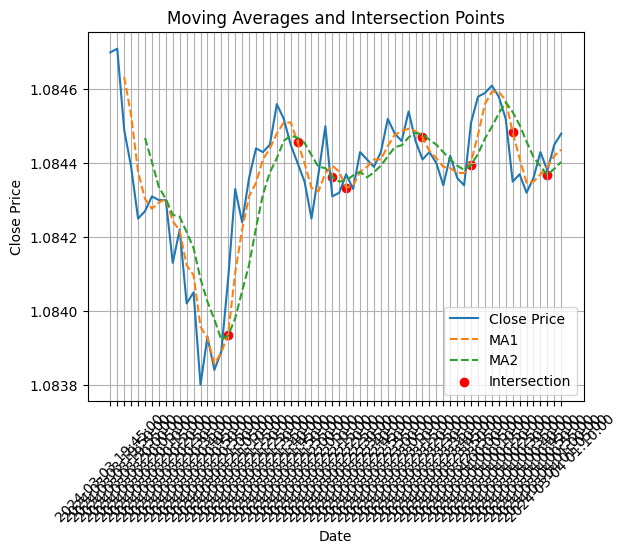

Intersection points:
               datetime       MA1       MA2
50  2024-03-03 21:10:00  1.083940  1.083933
60  2024-03-03 22:00:00  1.084457  1.084468
65  2024-03-03 22:25:00  1.084393  1.084363
67  2024-03-03 22:35:00  1.084333  1.084353
78  2024-03-03 23:30:00  1.084470  1.084478
85  2024-03-04 00:05:00  1.084403  1.084395
91  2024-03-04 00:35:00  1.084483  1.084538
96  2024-03-04 01:00:00  1.084390  1.084368


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
first_list = ['EURUSD']
df = dict()
for curr in first_list:
    d = pd.read_csv(f"common/MachineLearningModel/output/five_mins/{curr}_5_Min.csv")
    # cal = calculate(d)
    # pd_data.append(cal)d)
    # pd_data.append(cal)
    df = calculate_1(d.iloc[:100])
# df['MA1']  = sma_indicator(df['close'],window=3)
# df['MA2']  = sma_indicator(df['close'],window=6)
# plt.plot(df['datetime'], df['close'], label='Close Price')
# plt.plot(df['datetime'], df['MA1'], label='MA1', linestyle='--')
# plt.plot(df['datetime'], df['MA2'], label='MA2', linestyle='--')

# # Find intersections
# intersections = df[(df['MA1'] < df['MA2']) & (df['MA1'].shift(1) > df['MA2'].shift(1)) | 
#                    (df['MA1'] > df['MA2']) & (df['MA1'].shift(1) < df['MA2'].shift(1))]

# # Add column indicating if intersection occurred
# df['Intersection'] = False
# df.loc[intersections.index, 'Intersection'] = True
# df['Signal'] = 'Hold'
# df.loc[(df['Intersection']) & (df['MA1'] > df['MA2']), 'Signal'] = 'Buy'
# df.loc[(df['Intersection']) & (df['MA1'] < df['MA2']), 'Signal'] = 'Sell'
# print(df.iloc[-3,-1])
# print("Intersection points with buy/sell signal:")
# print(df[['datetime', 'MA1', 'MA2', 'Intersection', 'Signal']])
# # print("Intersection points:")
# # print(df[['datetime', 'MA1', 'MA2', 'Intersection']])


# # Read the data into a DataFrame
# data = """datetime,symbol,open,high,low,close,volume
# 2024-03-31 17:25:00,FX:EURAUD,1.6556899999999999,1.6556899999999999,1.65408,1.65408,1.0
# 2024-03-31 17:30:00,FX:EURAUD,1.65408,1.65484,1.65402,1.65439,104.0
# 2024-03-31 17:35:00,FX:EURAUD,1.65439,1.65459,1.65399,1.65402,68.0
# 2024-03-31 17:40:00,FX:EURAUD,1.65402,1.65402,1.65401,1.65402,139.0
# 2024-03-31 17:45:00,FX:EURAUD,1.65402,1.6546,1.65368,1.65453,81.0
# 2024-03-31 17:50:00,FX:EURAUD,1.65453,1.65466,1.65423,1.65424,207.0
# 2024-03-31 17:55:00,FX:EURAUD,1.65424,1.65435,1.65368,1.65417,392.0
# 2024-03-31 18:00:00,FX:EURAUD,1.65417,1.65454,1.65143,1.65154,1817.0
# 2024-03-31 18:05:00,FX:EURAUD,1.65154,1.65223,1.65154,1.65208,480.0"""

# df = pd.read_csv(pd.compat.StringIO(data), parse_dates=['datetime'])

# Calculate moving averages
window_size = 3  # Choose the window size for the moving average
df['MA1'] = df['close'].rolling(window=window_size).mean()
df['MA2'] = df['close'].rolling(window=window_size * 2).mean()

# Plot the original close price and moving averages
plt.plot(df['datetime'], df['close'], label='Close Price')
plt.plot(df['datetime'], df['MA1'], label='MA1', linestyle='--')
plt.plot(df['datetime'], df['MA2'], label='MA2', linestyle='--')

# Find intersections
intersections = df[(df['MA1'] < df['MA2']) & (df['MA1'].shift(1) > df['MA2'].shift(1)) | 
                   (df['MA1'] > df['MA2']) & (df['MA1'].shift(1) < df['MA2'].shift(1))]
plt.scatter(intersections['datetime'], intersections[['MA1', 'MA2']].min(axis=1), color='red', marker='o', label='Intersection')

plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.title('Moving Averages and Intersection Points')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

print("Intersection points:")
print(intersections[['datetime', 'MA1', 'MA2']])


In [7]:
# testing_data = pd.read_csv(f'common/MachineLearningModel/output/five_mins/testing_data.csv')
# test_data = calculate_1(testing_data)
# test_data.dropna(inplace=True)
# test_data.reset_index(drop=True,inplace=True)
# print(test_data.iloc[:,6:].head())
# print(test_data.shape)
# X_test = test_data.iloc[:,6:-1]
# y_test = test_data.iloc[:, -1]
# print(test_data.columns)
# print(X_test.columns)
# print(X_test.count())
# # print(y.head())
# X_test_train, X_test_test, y_test_train, y_test_test =train_test_split(
#   X_test, y_test, test_size = 0.99,train_size=0.01, shuffle=False)

In [8]:
# print(data.iloc[:,6:].head())

In [9]:
# data['rsi'] = data['rsi'].astype(dtype=int)
# data['cci'] = data['cci'].astype(dtype=int)
# data['adx'] = data['adx'].astype(dtype=int)
# data['adx_pos'] = data['adx_pos'].astype(dtype=int)
# data['adx_neg'] = data['adx_neg'].astype(dtype=int)

In [10]:
# data.drop(axis=1,labels=['rsi','cci','adx','macd','macd_signal','stochrsi','stochrsi_k','stochrsi_d'],inplace=True)
# data.drop(axis=1,labels=['RSI_1'],inplace=True)

In [22]:
data.dropna(inplace=True)
data.reset_index(drop=True,inplace=True)
print(data.iloc[:,6:].head())
print(data.shape)


   volume        rsi         cci        adx    adx_pos    adx_neg      macd  \
0  2837.0  72.618496  150.645342  41.265595  15.666606   3.877951  0.000156   
1  3863.0  72.919624  113.218606  41.923274  14.977224   4.929622  0.000165   
2  3301.0  57.847187   63.500440  40.854860  13.680624   7.869523  0.000152   
3  3699.0  52.531928    4.601077  38.889838  12.880078   9.847223  0.000132   
4  3487.0  46.139992  -66.246057  36.421900  12.086663  13.183043  0.000104   

   macd_signal  stochrsi_d  stochrsi_k  stochrsi  RSI  ADX  MCAD  SMA3  SMA6  \
0     0.000112    0.935348    0.935349  0.806048    2    1     1     2     2   
1     0.000123    0.932423    0.874758  0.818225    2    1     1     1     2   
2     0.000128    0.807033    0.610991  0.208699    0    1     1     1     1   
3     0.000129    0.609352    0.342308  0.000000    0    1     1     1     1   
4     0.000124    0.340955    0.069566  0.000000    0    2     2     1     1   

   Prediction  
0           2  
1           

In [23]:


le = LabelEncoder()
le.fit_transform(data['Prediction'])
print(le.classes_)


[0 1 2]


In [13]:
# import pickle
# combine_final_model = pickle.dump(stacking_clf, open('combineclassifier.sav','wb'))

In [24]:
print(data['Prediction'].value_counts())
X = data.iloc[:,7:-1]
y = data.iloc[:, -1]
print(data.columns)
print(X.columns)
print(X.count())
# print(y.head())
X_train, X_test, y_train, y_test =train_test_split(
  X, y, test_size = 0.30,train_size=0.70, shuffle=False)



Prediction
1    82322
2    81192
0    11110
Name: count, dtype: int64
Index(['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'rsi',
       'cci', 'adx', 'adx_pos', 'adx_neg', 'macd', 'macd_signal', 'stochrsi_d',
       'stochrsi_k', 'stochrsi', 'RSI', 'ADX', 'MCAD', 'SMA3', 'SMA6',
       'Prediction'],
      dtype='object')
Index(['rsi', 'cci', 'adx', 'adx_pos', 'adx_neg', 'macd', 'macd_signal',
       'stochrsi_d', 'stochrsi_k', 'stochrsi', 'RSI', 'ADX', 'MCAD', 'SMA3',
       'SMA6'],
      dtype='object')
rsi            174624
cci            174624
adx            174624
adx_pos        174624
adx_neg        174624
macd           174624
macd_signal    174624
stochrsi_d     174624
stochrsi_k     174624
stochrsi       174624
RSI            174624
ADX            174624
MCAD           174624
SMA3           174624
SMA6           174624
dtype: int64


In [15]:
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
# from sklearn.ensemble import StackingClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.datasets import make_classification
# # Define the base learners
# base_learners = [
#     ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
#     ('gb', GradientBoostingClassifier(n_estimators=10, random_state=42)),
#     ('xgb', XGBClassifier(booster="gbtree",max_depth=9,min_child_weight = 2))
# ]
# # Define the meta-learner
# meta_learner = LogisticRegression()
# # Build the Stacking classifier
# stacking_clf = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)
# # Train the Stacking classifier
# stacking_clf.fit(X_train, y_train)
# # Evaluate the model
# stacking_clf.score(X_test, y_test)

In [16]:
# final_comb_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)
# final_comb_model.fit(X,y)

In [17]:
# print(data_1['Prediction'].value_counts())
# X = data_1.iloc[:,6:-1]
# y = data_1.iloc[:, -1]
# print(data_1.columns)
# print(X.columns)
# print(X.count())
# # print(y.head())
# X_train, X_test, y_train, y_test =train_test_split(
#   X, y, test_size = 0.30, random_state = 24, shuffle=False)

In [25]:
# Initialize XGBoost classifier
xgb_model = XGBClassifier(booster="gbtree",max_depth=14,min_child_weight = 2)
# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
preds = xgb_model.predict(X_test)

# Evaluate the model
print(f"Accuracy on train data by XGBoost Classifier\
: {accuracy_score(y_train, xgb_model.predict(X_train))*100}")
 
print(f"Accuracy on test data by XGBoost Classifier\
: {accuracy_score(y_test, preds)*100}")


Accuracy on train data by XGBoost Classifier: 99.99590955201414
Accuracy on test data by XGBoost Classifier: 89.16736657249751


In [26]:

rf_model = RandomForestClassifier()
# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
preds = rf_model.predict(X_test)

# Evaluate the model
print(f"Accuracy on train data by RandomForest Classifier\
: {accuracy_score(y_train, rf_model.predict(X_train))*100}")
 
print(f"Accuracy on test data by RandomForest Classifier\
: {accuracy_score(y_test, preds)*100}")

Accuracy on train data by RandomForest Classifier: 100.0
Accuracy on test data by RandomForest Classifier: 87.76246468656944


In [23]:
final_rf_model = RandomForestClassifier()
final_rf_model.fit(X, y)

RandomForestClassifier()

In [24]:
final_xgb_model = XGBClassifier(booster="gbtree",max_depth=14,min_child_weight = 2)
final_xgb_model.fit(X, y)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=14, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [25]:
import pickle
xgb_final_model = pickle.dump(final_xgb_model, open('xgbclassifier_5_1.sav','wb'))
rf_final_model = pickle.dump(final_rf_model, open('rfclassifier_5_1.sav','wb'))

In [ ]:
from TradingDataGenerate import main
s = main.TvDatafeed('mageshragav1@gmail.com','Magesh1@')


In [ ]:
# def result(data):
#     pd_data_dump = calculate(data)
#     pd_data_dump.dropna(inplace=True)
#     pd_data_dump.reset_index()
#     print(pd_data_dump.iloc[-1])
#     data_1 = pd_data_dump.iloc[-1,5:-1].to_dict()
#     data_1 = pd.DataFrame({key: [int(value)] for key, value in data_1.items()})
#     print(data_1)
#     output_1 = final_comb_model.predict(pd.DataFrame(data_1))
#     print(output_1)

In [ ]:
def result_1(data):
    pd_data_dump = calculate_1(data)
    pd_data_dump.dropna(inplace=True)
    pd_data_dump.reset_index()
    # print(pd_data_dump.iloc[-1])
    data_1 = pd_data_dump.iloc[-1,5:-1].to_dict()
    data_1 = pd.DataFrame({key: [value] for key, value in data_1.items()})
    print(pd_data_dump.iloc[-1,0:4])
    print(data_1)
    print('\n')
    output = final_xgb_model.predict(pd.DataFrame(data_1))
    print(f"xgb classifier prediction {output}")
    output = final_rf_model.predict(pd.DataFrame(data_1))
    print(f"random forest classifier prediction {output}")

In [ ]:
# import random
# # symbols = random.choice(['EURUSD','EURJPY','GBPUSD','EURGBP'])
# EURUSD_data = s.get_hist(symbol="EURUSD",exchange='FX',interval=main.Interval.in_1_minute,n_bars=150,extended_session=False)
# EURUSD_data_1 = EURUSD_data.copy(deep=True)
# print('EURUSD')
# result(EURUSD_data)

In [ ]:
import math
EURUSD_data_1 = s.get_hist(symbol="EURUSD",exchange='FX',interval=main.Interval.in_5_minute,n_bars=150,extended_session=False)
result_1(EURUSD_data_1)
cci_os = cci(EURUSD_data_1['high'],EURUSD_data_1['low'],EURUSD_data_1['close'],21)
sma_trend_high = sma_indicator(EURUSD_data_1['close'],3)
sma_trend_low = sma_indicator(EURUSD_data_1['close'],6)

sma_3 = sma_indicator(EURUSD_data_1['close'],window=3)
sma_6 = sma_indicator(EURUSD_data_1['close'],window=6)
sma_last_1 = sma_3.iloc[-1]
sma_last_2 = sma_6.iloc[-1]

nearby = math.isclose(sma_3.iloc[-2],sma_6.iloc[-2], abs_tol=0.0001)
nearby_2 = math.isclose(sma_3.iloc[-3],sma_6.iloc[-3], abs_tol=0.0001)
print(f"nearby 2 value {nearby_2}, nearby 1 value{nearby}")
print(f"sma values: {sma_last_1} and {sma_last_2}")
rsi_13 = rsi(EURUSD_data_1['close'],13).iloc[-1]
if (sma_last_1 > sma_last_2) and (25 < rsi_13 < 65) and (nearby or nearby_2):
    print('BUY')
elif (sma_last_1 < sma_last_2) and (65 > rsi_13 > 25) and (nearby or nearby_2):
    print('SELL')
else:
    print('NEUTRAL')

In [ ]:
import mplfinance as mpf
df = EURUSD_data_1
mpf.plot(df,type='candle', style='charles',mav=(3,6), volume=True)


In [ ]:
from tradingview_ta import TA_Handler, Interval, Exchange
import tradingview_ta
handler = TA_Handler(
    symbol="EURUSD",
    exchange="FX_IDC",
    screener="forex",
    interval="5m",
    timeout=None
)
ss = handler.get_analysis()
print(ss.oscillators)